# <b><u>DECODE LABS</u></b>
## <u>Supervised Learning (Fraud Detection Pipeline)</u>
### 🎯 Objective

The objective of this project is to build a supervised machine learning model capable of identifying fraudulent credit card transactions. The project focuses on preprocessing the dataset, handling class imbalance using SMOTE, training multiple classification algorithms, and evaluating their performance using appropriate metrics such as Precision, Recall, F1-Score, and ROC-AUC. The ultimate goal is to develop a reliable fraud detection pipeline that can accurately distinguish fraudulent transactions from legitimate ones.

### Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


### Loading Data

In [2]:
df = pd.read_csv("../data/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. EDA

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 1081


In [9]:
class_counts = df["Class"].value_counts()
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

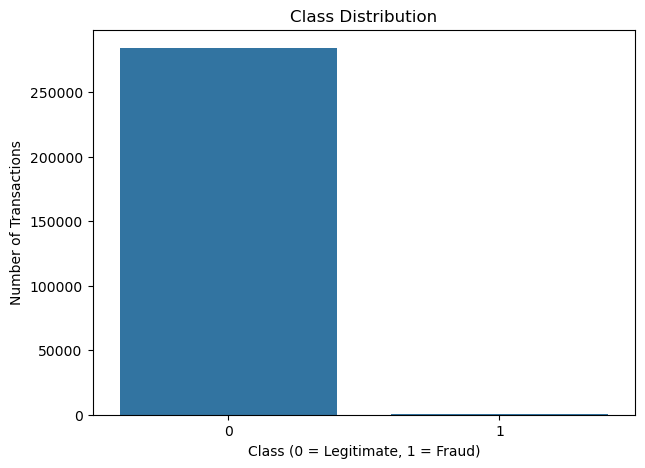

In [10]:
plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1])
plt.show()

In [11]:
fraud_rate = df["Class"].mean()
print(f"Fraud rate: {fraud_rate:.2%}")
print(f"Legitimate transactions: {(df['Class'] == 0).sum():,}")
print(f"Fraudulent transactions: {(df['Class'] == 1).sum():,}")

Fraud rate: 0.17%
Legitimate transactions: 284,315
Fraudulent transactions: 492


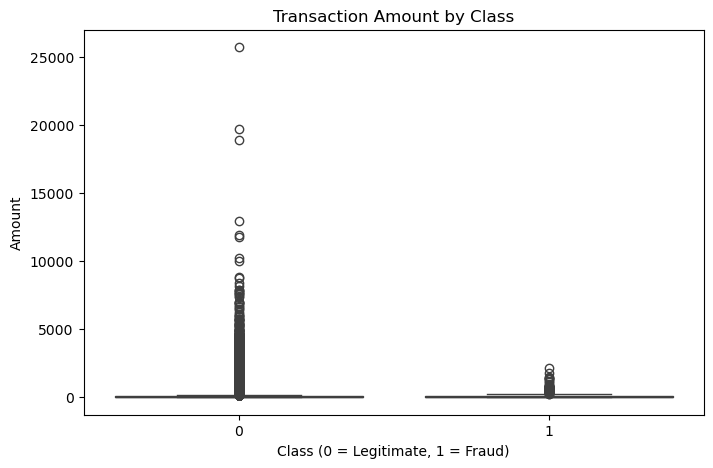

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Amount")
plt.show()

#### Insights :-
The dataset is highly imbalanced, with fraudulent transactions forming only a very small percentage of all transactions. This makes Accuracy a poor primary metric. Precision, Recall, F1-Score and ROC-AUC are more informative for this fraud-detection problem.

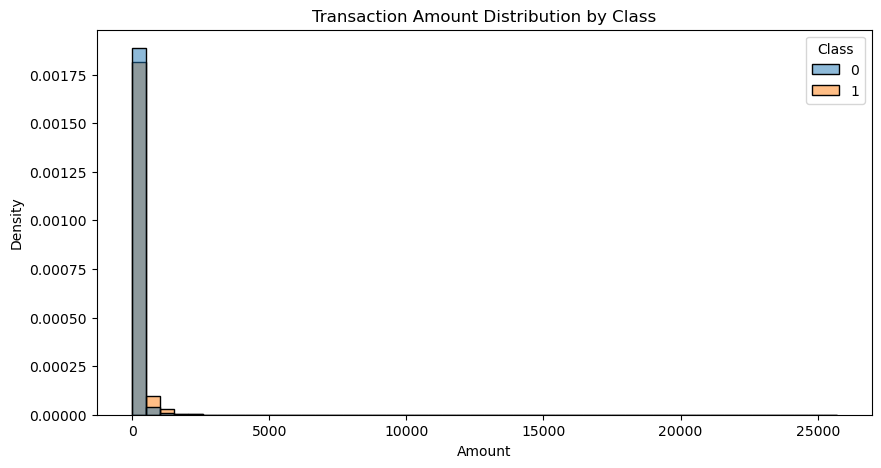

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    stat="density",
    common_norm=False
)
plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.show()

#### Insights :-
Transaction amounts have different distributions across legitimate and fraudulent transactions, but there is substantial overlap. Therefore, the model needs to combine multiple features rather than relying on Amount alone.

### EDA Conclusion

The dataset contains anonymized numerical features V1-V28, along with transaction Amount and the fraud target Class. The target is severely imbalanced, so the modeling pipeline must address class imbalance and use evaluation metrics that focus on fraud detection rather than Accuracy.

## 2. Preprocessing

### Preparing Features

In [14]:
# Drop the target from X. Keep the numerical V1-V28 and Amount features.
X = df.drop(columns=["Class"])
y = df["Class"]

In [15]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


### Train/Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\ny_train:")
print(y_train.value_counts())
print("\ny_test:")
print(y_test.value_counts())

X_train: (227845, 30)
X_test : (56962, 30)

y_train:
Class
0    227451
1       394
Name: count, dtype: int64

y_test:
Class
0    56864
1       98
Name: count, dtype: int64


### Why this split?
We split the data before applying SMOTE. This is essential because the test set must remain completely untouched. We use stratify=y so the fraud/legitimate ratio is preserved in both sets.

## 3. Leak-Free SMOTE + Model Pipelines

SMOTE is applied only inside the training pipeline. This prevents synthetic samples from influencing the validation/test data during model selection.

### Logistic Regression Pipeline

In [18]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

### Random Forest Pipeline
Random Forest does not require feature scaling, but SMOTE is still kept inside the pipeline so it is applied safely during cross-validation.

In [19]:
random_forest_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

### Model Pipelines

In [20]:
print("Pipelines created successfully.")

Pipelines created successfully.


## 4. Hyperparameter Tuning with GridSearchCV

### Logistic Regression

In [21]:
logistic_params = {
    "smote__k_neighbors": [3, 5],
    "classifier__C": [0.1, 1, 10]
}

logistic_grid = GridSearchCV(
    logistic_pipeline,
    param_grid=logistic_params,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

logistic_grid.fit(X_train, y_train)

print("Best Logistic Regression parameters:")
print(logistic_grid.best_params_)
print("Best CV ROC-AUC:", logistic_grid.best_score_)

Best Logistic Regression parameters:
{'classifier__C': 0.1, 'smote__k_neighbors': 5}
Best CV ROC-AUC: 0.9806193896825396


In [22]:
best_logistic = logistic_grid.best_estimator_

y_pred_lr = best_logistic.predict(X_test)
y_prob_lr = best_logistic.predict_proba(X_test)[:, 1]

In [23]:
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {roc_auc_lr:.4f}")
print("\nConfusion Matrix:")
print(cm_lr)

Precision : 0.0582
Recall    : 0.9184
F1-Score  : 0.1094
ROC-AUC   : 0.9709

Confusion Matrix:
[[55407  1457]
 [    8    90]]


### Random Forest

In [24]:
random_forest_params = {
    "smote__k_neighbors": [5],
    "classifier__n_estimators": [100],
    "classifier__max_depth": [None, 20]
}

random_forest_grid = GridSearchCV(
    random_forest_pipeline,
    param_grid=random_forest_params,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

random_forest_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(random_forest_grid.best_params_)
print("Best CV ROC-AUC:", random_forest_grid.best_score_)

Best Random Forest parameters:
{'classifier__max_depth': 20, 'classifier__n_estimators': 100, 'smote__k_neighbors': 5}
Best CV ROC-AUC: 0.9694161846012873


In [25]:
best_random_forest = random_forest_grid.best_estimator_

y_pred_rf = best_random_forest.predict(X_test)
y_prob_rf = best_random_forest.predict_proba(X_test)[:, 1]

In [26]:
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")
print("\nConfusion Matrix:")
print(cm_rf)

Precision : 0.7810
Recall    : 0.8367
F1-Score  : 0.8079
ROC-AUC   : 0.9768

Confusion Matrix:
[[56841    23]
 [   16    82]]


## 5. Compare Both Tuned Models

In [27]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1-Score": [f1_lr, f1_rf],
    "ROC-AUC": [roc_auc_lr, roc_auc_rf]
})

results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.058177,0.918367,0.109422,0.970872
1,Random Forest,0.780952,0.836735,0.807882,0.976757


In [28]:
print("Logistic Regression Confusion Matrix:")
print(cm_lr)

print("\nRandom Forest Confusion Matrix:")
print(cm_rf)

Logistic Regression Confusion Matrix:
[[55407  1457]
 [    8    90]]

Random Forest Confusion Matrix:
[[56841    23]
 [   16    82]]


## 6. Final Conclusion

This project built a supervised fraud-detection pipeline using the anonymized V1-V28 features, transaction Amount, and the Class target.

The dataset is highly imbalanced, so SMOTE was used only inside the training pipelines. The train/test split was performed before SMOTE, ensuring that the test set remained untouched and preventing data leakage.

Two supervised learning algorithms were trained and tuned: Logistic Regression and Random Forest. GridSearchCV was used with stratified cross-validation and ROC-AUC as the tuning metric.

The final models were evaluated on the untouched test set using Precision, Recall, F1-Score, ROC-AUC, and confusion matrices. Accuracy was deliberately not used as the main metric because a model can achieve very high accuracy while missing most fraudulent transactions.

The better model should be selected based on the fraud-detection objective, especially the trade-off between Recall (catching more fraud) and Precision (reducing false fraud alerts), rather than Accuracy alone.

**Results:** Logistic Regression achieved higher Recall (0.918 vs 0.837) but extremely poor Precision (0.058 vs 0.781) — it flagged 1,457 legitimate transactions as fraud to catch 90 true frauds, an unusable false-alarm rate in a live payment system. Random Forest caught slightly less fraud (82 vs 90 out of 98) but with far fewer false alarms (23 vs 1,457) and a substantially better F1-Score (0.808 vs 0.109) and ROC-AUC (0.977 vs 0.971).

**Conclusion:** Random Forest is the stronger model for this task. Its balance of high Recall and high Precision makes it far more deployable — a system that blocks 1,457 legitimate customer transactions to catch 8 extra fraud cases would cause serious customer-experience and business damage, even though its Recall alone looks strong. This illustrates why Accuracy and even Recall in isolation can be misleading for imbalanced classification, and why Precision, Recall, F1, and ROC-AUC need to be read together against the real-world cost of false positives vs false negatives.